----------------------------------------------
Import dataset and necessary libraries
----------------------------------------------
----------------------------------------------

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import RobustScaler, LabelEncoder
from numpy import unique, argmax
from scipy.stats.mstats import winsorize
from scipy.signal import butter, filtfilt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, accuracy_score, classification_report
import tensorflow as tf
from tensorflow.keras.models import Model # type: ignore
from tensorflow.keras.layers import Input, Dense, Dropout # type: ignore
from tensorflow.keras.callbacks import EarlyStopping # type: ignore
from tensorflow.keras.utils import plot_model # type: ignore

df_beam = pd.read_csv("dataset_beam.csv")

print(f"Number of columns: {df_beam.shape[1]}")
print(f"Number of rows: {df_beam.shape[0]}")

pd.set_option('display.width', 1000)
print(df_beam.head())

Number of columns: 30
Number of rows: 3600
  mechanism severity  beam_cm  target_class  distance_crack_cm  distance_wear_cm  crack_mask  wear_mask      FC_Hz    FRMS_Hz  ...  f2_Hz  f3_Hz  f4_Hz  f5_Hz                                          file_path           folder_all  all_index  segment_id   t0     t1
0   healthy     none     10.0             0                0.0               0.0           0          0  21.162511  38.493772  ...   58.0   58.4   57.8   57.6  C:\Users\axelr\OneDrive\Escritorio\Proyecto3\b...              ALL0000          0           1  0.0  4.998
1   healthy     none     10.0             0                0.0               0.0           0          0  18.000610  36.218075  ...   57.6   57.4   57.2   57.0  C:\Users\axelr\OneDrive\Escritorio\Proyecto3\b...      ALL0000 - copia          0           1  0.0  4.998
2   healthy     none     10.0             0                0.0               0.0           0          0  12.107835  31.007700  ...   58.0   57.6   57.4   57.2 

----------------------------------------------
Verifying data types
----------------------------------------------
----------------------------------------------

In [2]:
print("Data Types:")
print(df_beam.info())

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   mechanism          3600 non-null   object 
 1   severity           3600 non-null   object 
 2   beam_cm            3600 non-null   float64
 3   target_class       3600 non-null   int64  
 4   distance_crack_cm  3600 non-null   float64
 5   distance_wear_cm   3600 non-null   float64
 6   crack_mask         3600 non-null   int64  
 7   wear_mask          3600 non-null   int64  
 8   FC_Hz              3600 non-null   float64
 9   FRMS_Hz            3600 non-null   float64
 10  FRVF_Hz            3600 non-null   float64
 11  m0                 3600 non-null   float64
 12  m1                 3600 non-null   float64
 13  m2                 3600 non-null   float64
 14  a1                 3600 non-null   float64
 15  a2                 3600 non-null   float64
 16  a3          

----------------------------------------------
Checking for duplicate rows
----------------------------------------------
----------------------------------------------

In [3]:
duplicated = df_beam.duplicated().sum()

if duplicated > 0:
    print(f"{duplicated} duplicated rows in the train set.")
    print("Display of duplicate rows:")
    print(df_beam[df_beam.duplicated()].head())
else:
    print("No duplicate rows were found in the dataset.")

No duplicate rows were found in the dataset.


----------------------------------------------
Obtaining only columns with characteristics
----------------------------------------------
----------------------------------------------

In [4]:
base_cols = [
        "target_class","distance_crack_cm","distance_wear_cm",
        "FC_Hz","FRMS_Hz","FRVF_Hz","m0","m1","m2","a1",
        "a2","a3","a4","a5","f1_Hz","f2_Hz","f3_Hz","f4_Hz","f5_Hz"
    ]

label_cols = ["target_class","distance_crack_cm","distance_wear_cm","crack_mask","wear_mask"]
feature_cols = [c for c in base_cols if c not in label_cols]

labels = df_beam[label_cols].copy()
df_beam_cols = df_beam[feature_cols].copy()


----------------------------------------------
Correlation Map
----------------------------------------------
----------------------------------------------

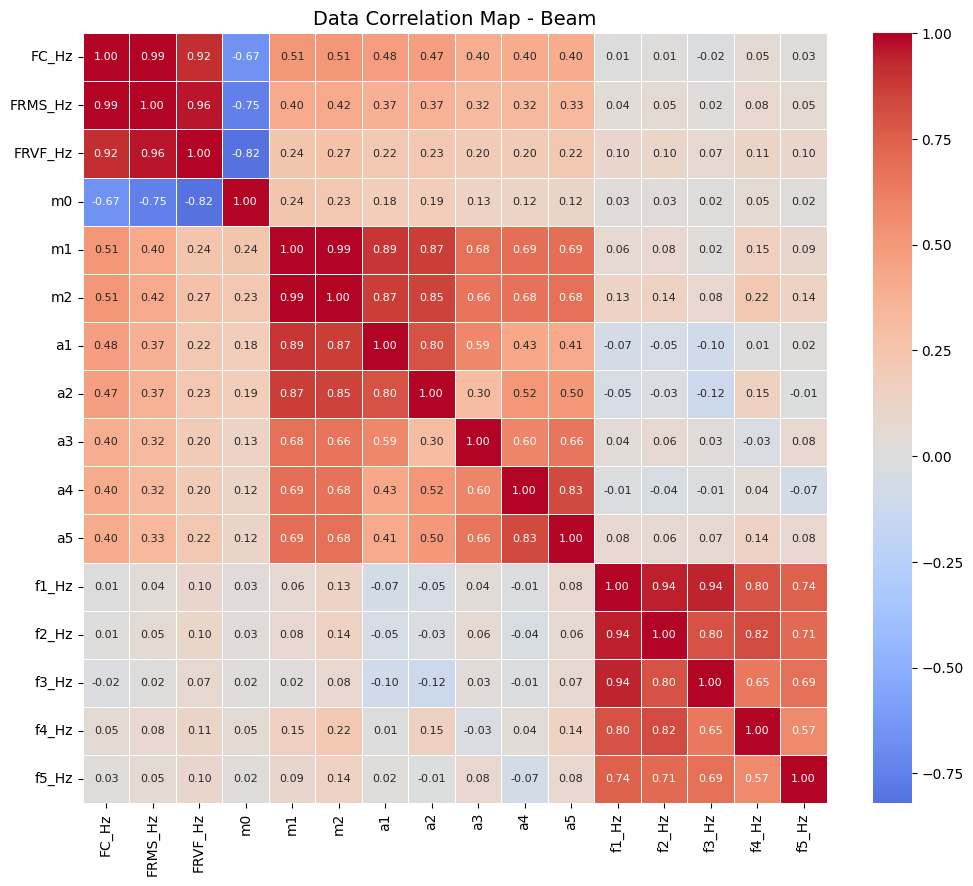

In [5]:
plt.figure(figsize=(12,10)) 
sns.heatmap(df_beam_cols.corr(method='spearman'), annot=True, fmt=".2f", cmap="coolwarm", center=0, 
            linewidths=0.5, annot_kws={"size": 8}) 
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title("Data Correlation Map - Beam", fontsize=14)
plt.show()

----------------------------------------------
Distribution of attributes
----------------------------------------------
----------------------------------------------

Original distributions:


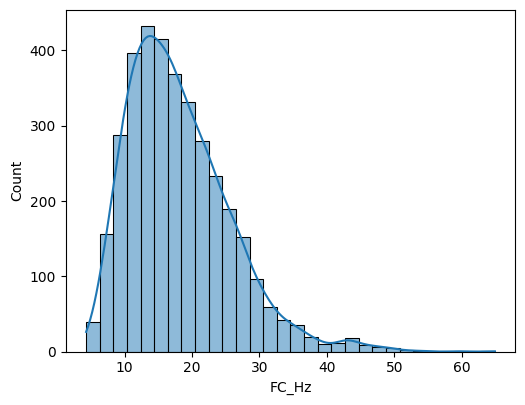

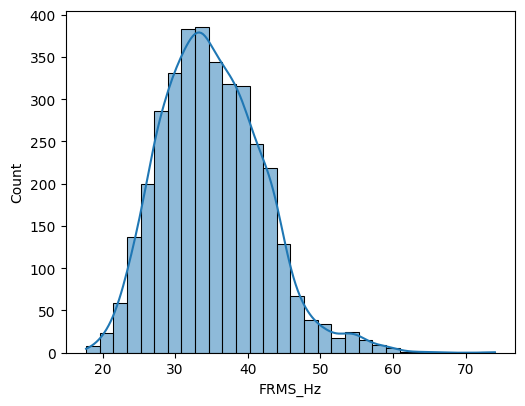

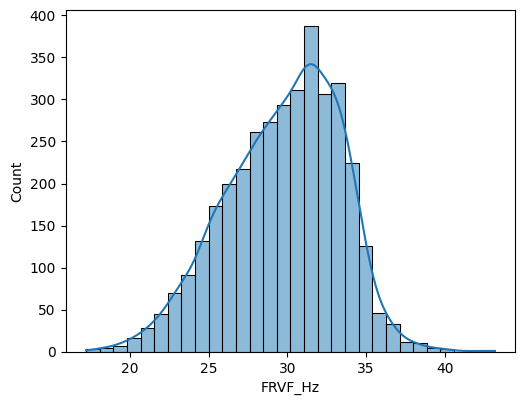

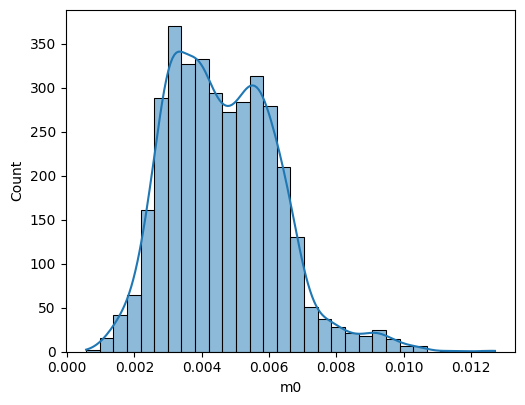

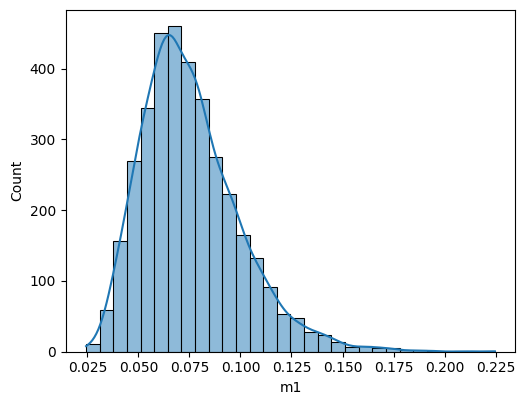

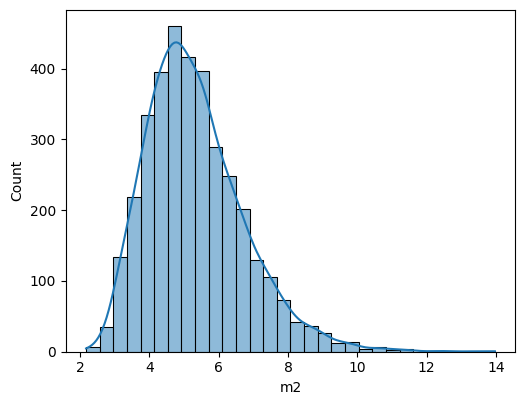

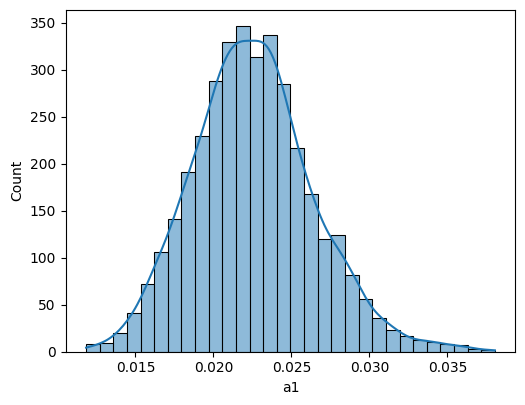

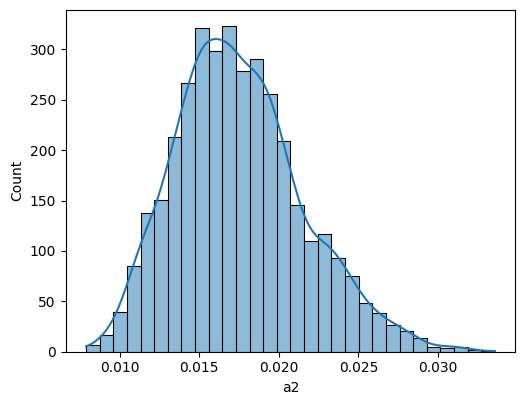

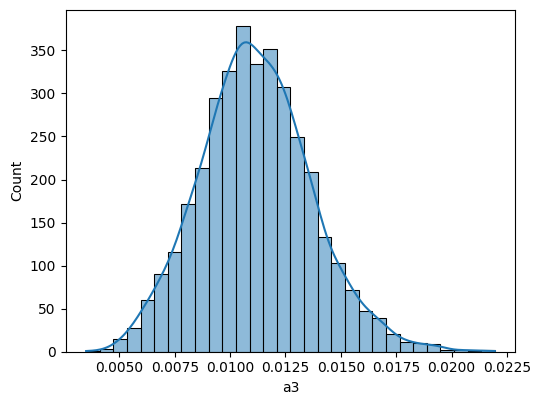

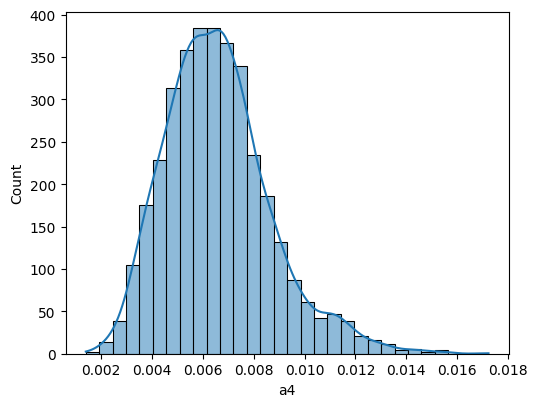

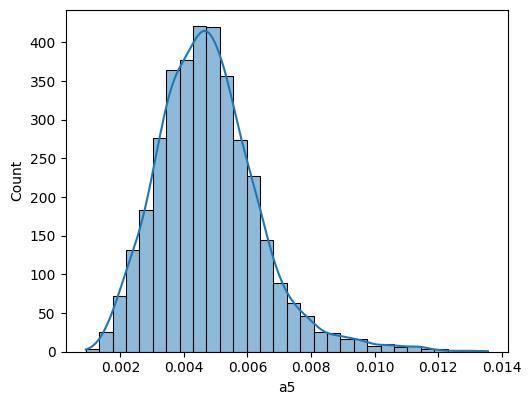

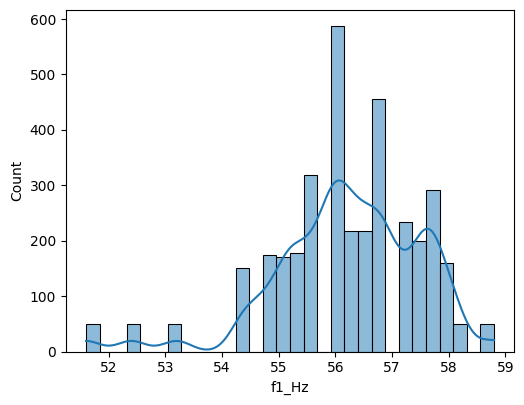

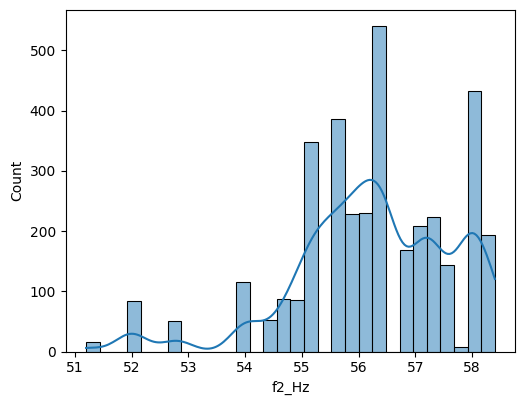

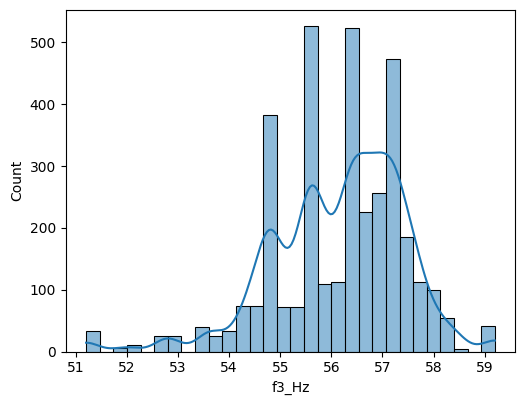

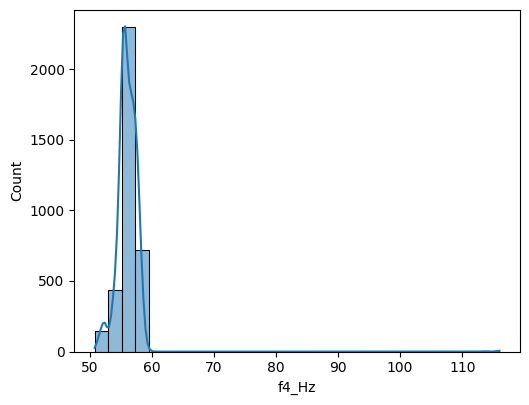

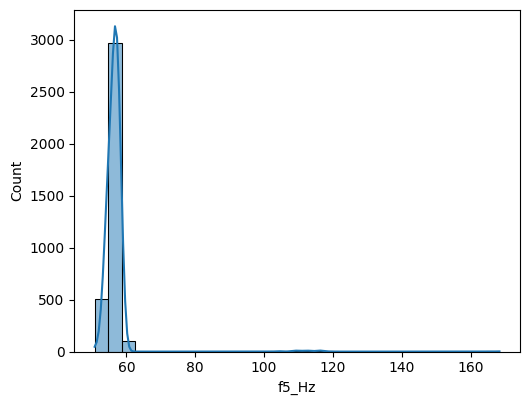

In [6]:
print("Original distributions:")

for i, col in enumerate(df_beam_cols):
    plt.figure(figsize=(10, len(df_beam_cols) * 4))
    plt.subplot(len(df_beam_cols), 2, 2 * i + 1)
    sns.histplot(df_beam_cols[col], kde=True, bins=30)
    plt.tight_layout()
    plt.show()

----------------------------------------------
Dataset splitting
----------------------------------------------
----------------------------------------------

In [7]:
import os, random, numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED)

# Features
dfX = df_beam_cols.copy()
lbl = labels.copy()
assert (dfX.index == lbl.index).all(), "df_beam_cols and labels must be index-aligned."

# Targets + masks
y_cls  = lbl["target_class"].astype("int32").values
y_crack  = lbl["distance_crack_cm"].astype("float32").values
y_wear = lbl["distance_wear_cm"].astype("float32").values
sw_crack  = lbl["crack_mask"].astype("float32").values
sw_wear = lbl["wear_mask"].astype("float32").values

feature_names = list(dfX.columns)

X_all = dfX[feature_names].astype("float32").values
print(f"[X] Using {len(feature_names)} features.")

X_tr, X_te, \
y_cls_tr, y_cls_te, \
y_crack_tr, y_crack_te, \
y_wear_tr, y_wear_te, \
sw_crack_tr, sw_crack_te, \
sw_wear_tr, sw_wear_te = train_test_split(
    X_all, y_cls, y_crack, y_wear, sw_crack, sw_wear,
    test_size=0.20, random_state=SEED, stratify=y_cls
)

print(f"[Split] train={X_tr.shape[0]}  test={X_te.shape[0]}")

[X] Using 16 features.
[Split] train=2880  test=720


----------------------------------------------
Attribute transformations
----------------------------------------------
----------------------------------------------

In [8]:
import numpy as np
from sklearn.preprocessing import PowerTransformer

cols_yeojohnson = ["FC_Hz","FRVF_Hz","FRMS_Hz","m0","m1","m2","a1","a2","a3","a4","a5"]

cols_present = [c for c in cols_yeojohnson if c in feature_names]
idx_yj = [feature_names.index(c) for c in cols_present]

print(f"[YJ] Requested={len(cols_yeojohnson)}  Present_in_features={len(cols_present)}")
if len(cols_present) > 0:
    print("[YJ] Applying to:", cols_present)

    X_tr = X_tr.copy()
    X_te = X_te.copy()

    X_tr_raw = X_tr.copy()

    Xtr_yj = X_tr[:, idx_yj].astype(np.float64, copy=True)
    Xte_yj = X_te[:, idx_yj].astype(np.float64, copy=True)

    if not np.isfinite(Xtr_yj).all():
        bad = np.where(~np.isfinite(Xtr_yj))
        raise ValueError(f"[YJ] Non-finite values in TRAIN at rows={bad[0][:10]} cols={bad[1][:10]}")
    if not np.isfinite(Xte_yj).all():
        bad = np.where(~np.isfinite(Xte_yj))
        raise ValueError(f"[YJ] Non-finite values in TEST at rows={bad[0][:10]} cols={bad[1][:10]}")

    pt_yj = PowerTransformer(method="yeo-johnson", standardize=False)

    Xtr_yj = pt_yj.fit_transform(Xtr_yj) 
    Xte_yj = pt_yj.transform(Xte_yj)     

    X_tr[:, idx_yj] = Xtr_yj
    X_te[:, idx_yj] = Xte_yj

else:
    print("[YJ] None of the requested columns exist in feature_names. Skipping YJ.")
    pt_yj = None

[YJ] Requested=11  Present_in_features=11
[YJ] Applying to: ['FC_Hz', 'FRVF_Hz', 'FRMS_Hz', 'm0', 'm1', 'm2', 'a1', 'a2', 'a3', 'a4', 'a5']


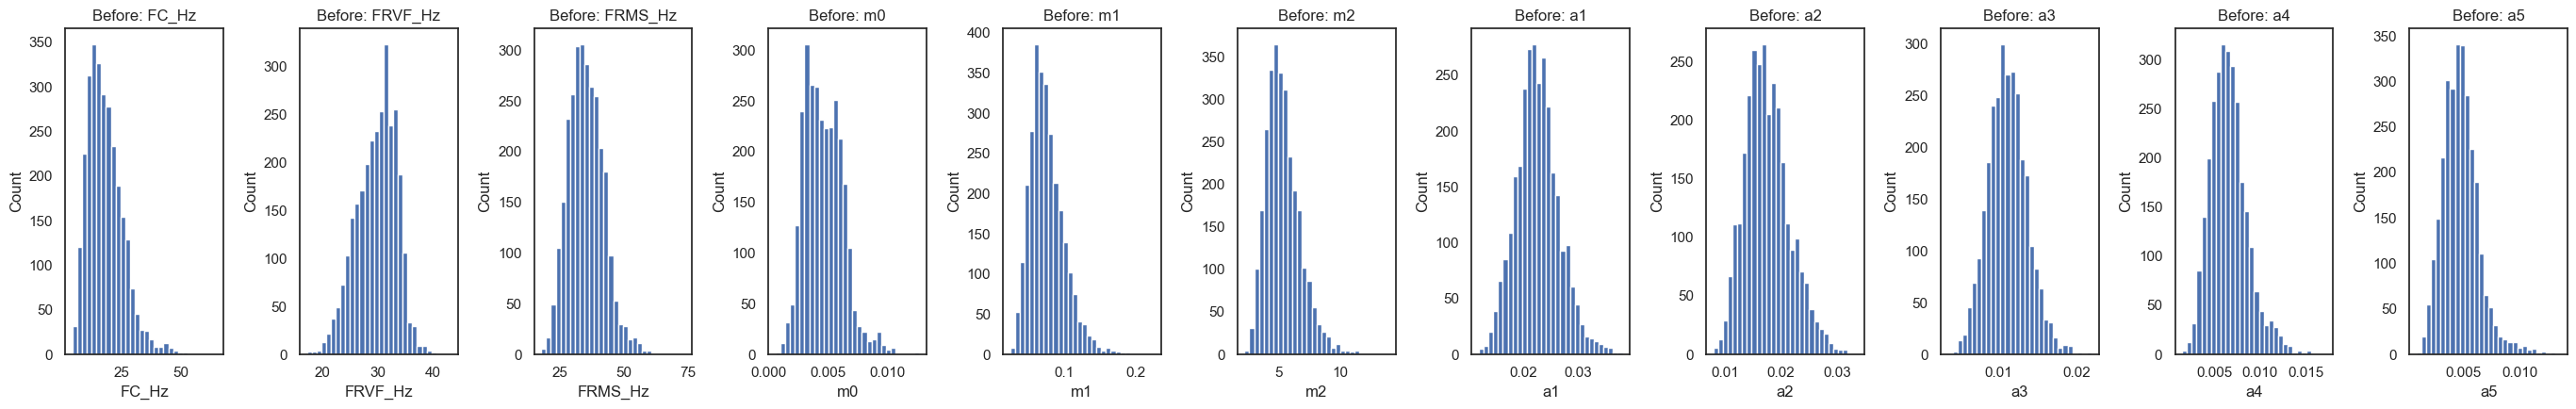

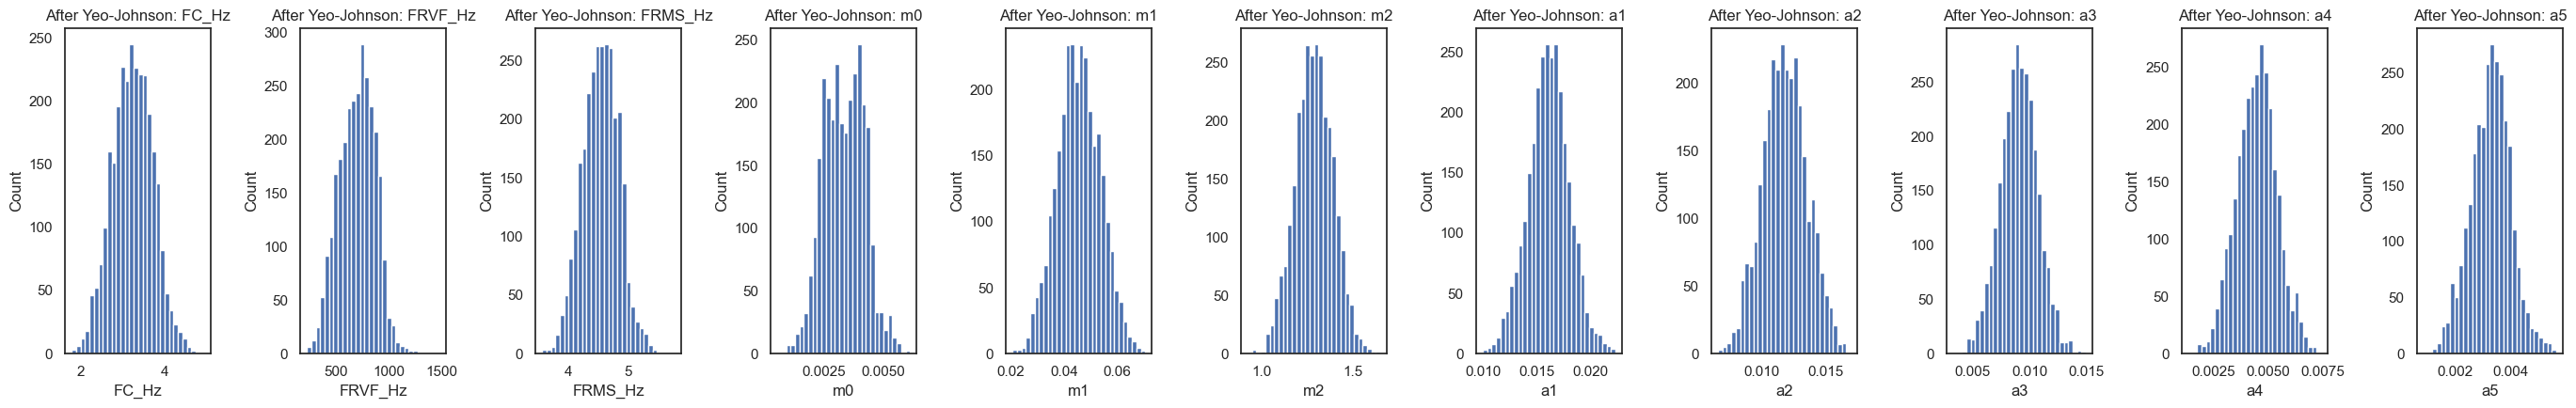

    feature  skew_before  skew_after  abs_reduction
0     FC_Hz     1.056551   -0.001993       1.054558
1        m1     1.054285    0.027622       1.026663
2        m2     0.998801    0.001790       0.997011
3        a5     0.966223   -0.014352       0.951871
4        a4     0.793192    0.006438       0.786754
5        m0     0.642915    0.023544       0.619371
6   FRMS_Hz     0.509830   -0.000368       0.509461
7        a2     0.519547    0.017554       0.501994
8        a1     0.390483   -0.004353       0.386130
9   FRVF_Hz    -0.374309   -0.031823       0.342485
10       a3     0.303779   -0.002868       0.300912


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew

sns.set_theme(style="white")

# Histograms (train: before vs after) ----
n = len(cols_present)
fig_w = max(14, 2.5 * n)
fig_h = 4.5

# A) Before
plt.figure(figsize=(fig_w, fig_h))
for i, (c, j) in enumerate(zip(cols_present, idx_yj), start=1):
    ax = plt.subplot(1, n, i)
    ax.hist(X_tr_raw[:, j], bins=30)
    ax.set_title(f"Before: {c}")
    ax.set_xlabel(c)
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

# B) After
plt.figure(figsize=(fig_w, fig_h))
for i, (c, j) in enumerate(zip(cols_present, idx_yj), start=1):
    ax = plt.subplot(1, n, i)
    ax.hist(X_tr[:, j], bins=30)
    ax.set_title(f"After Yeo-Johnson: {c}")
    ax.set_xlabel(c)
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

# ---- 4) Comparative table of skewness (train) ----
rows = []
for c, j in zip(cols_present, idx_yj):
    sk_before = float(skew(X_tr_raw[:, j], bias=False, nan_policy="omit"))
    sk_after  = float(skew(X_tr[:, j],     bias=False, nan_policy="omit"))
    rows.append({
        "feature": c,
        "skew_before": sk_before,
        "skew_after": sk_after,
        "abs_reduction": abs(sk_before) - abs(sk_after),
    })

df_skew = pd.DataFrame(rows).sort_values("abs_reduction", ascending=False).reset_index(drop=True)

with pd.option_context("display.max_rows", 200, "display.max_columns", 20, "display.width", 160):
    print(df_skew)

[Winsor] Requested=2  Present_in_features=2

=== Winsorize superior (alpha=0.010 -> quantil 0.990) FIT in train ===
Variable Cap_train(q)  Replaced_train %_train
   f4_Hz    58.400002              12   0.42%
   f5_Hz    58.799999              25   0.87%


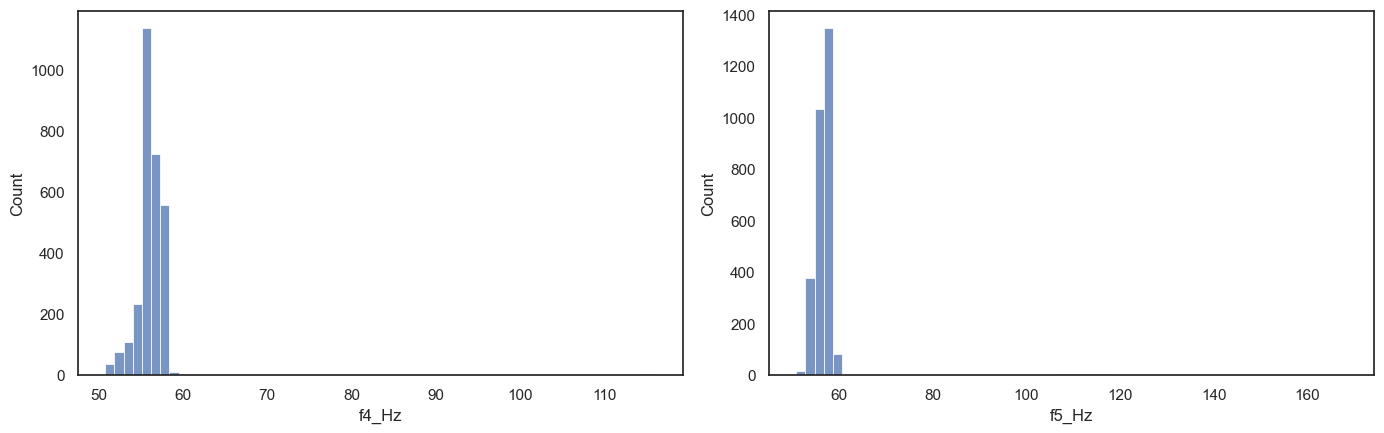

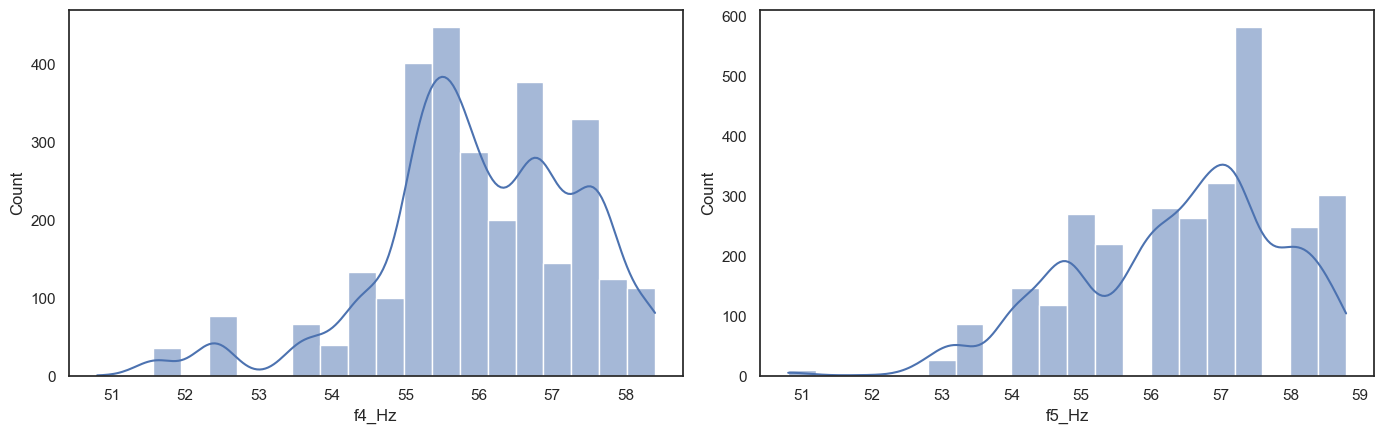

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

UPPER_ALPHA = 0.01
cols_win = ["f4_Hz", "f5_Hz"]

cols_present = [c for c in cols_win if c in feature_names]
idx_win = [feature_names.index(c) for c in cols_present]

print(f"[Winsor] Requested={len(cols_win)}  Present_in_features={len(cols_present)}")
if len(cols_present) == 0:
    print("[Winsor] None of the requested columns exist in feature_names. Skipping.")
else:
    X_tr = X_tr.copy()
    X_te = X_te.copy()

    X_tr_win_raw = X_tr[:, idx_win].copy()

    # 1) Thresholds (cap) calculated ONLY in train
    caps = np.quantile(X_tr[:, idx_win], 1.0 - UPPER_ALPHA, axis=0)

    # 2) Apply top winsorize as clipping: x = min(x, cap_train)
    X_tr[:, idx_win] = np.minimum(X_tr[:, idx_win], caps)
    X_te[:, idx_win] = np.minimum(X_te[:, idx_win], caps)

    # 3) Comparative table of replacements (train and test)
    stats = []
    for k, c in enumerate(cols_present):
        cap = float(caps[k])

        tr_before = X_tr_win_raw[:, k]
        tr_after  = X_tr[:, idx_win[k]]

        n_tr = tr_before.size
        n_tr_repl = int(np.sum(tr_before > cap))
        pct_tr = 100.0 * n_tr_repl / n_tr if n_tr else 0.0

        stats.append([c, cap, n_tr_repl, pct_tr])

    df_wins = pd.DataFrame(
        stats,
        columns=["Variable", "Cap_train(q)", "Replaced_train", "%_train"]
    )

    print(f"\n=== Winsorize superior (alpha={UPPER_ALPHA:.3f} -> quantil {1-UPPER_ALPHA:.3f}) FIT in train ===")
    print(df_wins.to_string(index=False, formatters={
        "Cap_train(q)": "{:.6f}".format,
        "%_train": "{:.2f}%".format
    }))

    # 4) Histograms (TRAIN before vs after)
    n = len(cols_present)
    fig_w = max(14, 2.6 * n)
    fig_h = 4.5

    # Before
    fig, axes = plt.subplots(1, n, figsize=(fig_w, fig_h))
    if n == 1:
        axes = [axes]

    for ax, (i, c) in zip(axes, enumerate(cols_present)):
        sns.histplot(X_tr_win_raw[:, i], bins=60, ax=ax, kde=False)
        #ax.set_title(f"Train before: {c}")
        ax.set_xlabel(c)
        ax.set_ylabel("Count")

    plt.tight_layout()
    plt.show()

    # After
    fig, axes = plt.subplots(1, n, figsize=(fig_w, fig_h))
    if n == 1:
        axes = [axes]

    for ax, (i, c) in zip(axes, enumerate(cols_present)):
        sns.histplot(X_tr[:, idx_win[i]], bins=20, ax=ax, kde=True)
        #ax.set_title(f"Train after winsorize↑: {c}")
        ax.set_xlabel(c)
        ax.set_ylabel("Count")

    plt.tight_layout()
    plt.show()

In [11]:
import numpy as np
import pandas as pd

_req = ["X_tr_raw", "X_tr", "feature_names", "y_cls_tr"]
assert all(v in globals() for v in _req), \
    "Missing variables. Need X_tr_raw (before), X_tr (after), feature_names, y_cls_tr."

df_before = pd.DataFrame(X_tr_raw, columns=feature_names).copy()
df_after  = pd.DataFrame(X_tr,     columns=feature_names).copy()

HUE_COL = "target_class"
df_before[HUE_COL] = y_cls_tr.astype(int)
df_after[HUE_COL]  = y_cls_tr.astype(int)

print("[Pairplot] df_before shape:", df_before.shape)
print("[Pairplot] df_after  shape:", df_after.shape)

[Pairplot] df_before shape: (2880, 17)
[Pairplot] df_after  shape: (2880, 17)


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="white")

def make_pairplot_inline(df, cols, hue, title, sample=500):
    cols_present = [c for c in cols if c in df.columns]
    if len(cols_present) == 0:
        print(f"[Pairplot] Skipping '{title}' (no columns present).")
        return

    d = df[[hue] + cols_present].replace([np.inf, -np.inf], np.nan).dropna().copy()

    if len(d) == 0:
        print(f"[Pairplot] Skipping '{title}' (no rows after dropna).")
        return

    if len(d) > sample:
        d = d.sample(sample, random_state=42)

    d[hue] = d[hue].astype("category")

    g = sns.pairplot(
        d, vars=cols_present, hue=hue,
        diag_kind="kde",
        kind="scatter",
        height=1.5,
        aspect=1.0,
        plot_kws=dict(s=12, alpha=0.6, edgecolor="none")
    )

    g.fig.suptitle(title, y=1.05, fontsize=12)

    for ax in g.axes.flatten():
        if ax is not None:
            ax.tick_params(labelsize=7)

    if g._legend is not None:
        leg = g._legend

        if hasattr(leg, "legend_handles"):
            handles = leg.legend_handles
        elif hasattr(leg, "legendHandles"):
            handles = leg.legendHandles
        else:
            handles, _ = leg.axes.get_legend_handles_labels()

        labels = [t.get_text() for t in leg.get_texts()]
        n_classes = max(1, len(labels))

        leg.remove()

        g.fig.legend(
            handles, labels,
            title="Class",
            loc="upper center",
            bbox_to_anchor=(0.5, 1.02),
            ncol=n_classes,
            fontsize=10,
            title_fontsize=8,
            frameon=False
        )

    g.fig.subplots_adjust(
        top=0.97,
        bottom=0.05,
        left=0.05,
        right=0.98,
        wspace=0.02,
        hspace=0.02
    )

    plt.show()

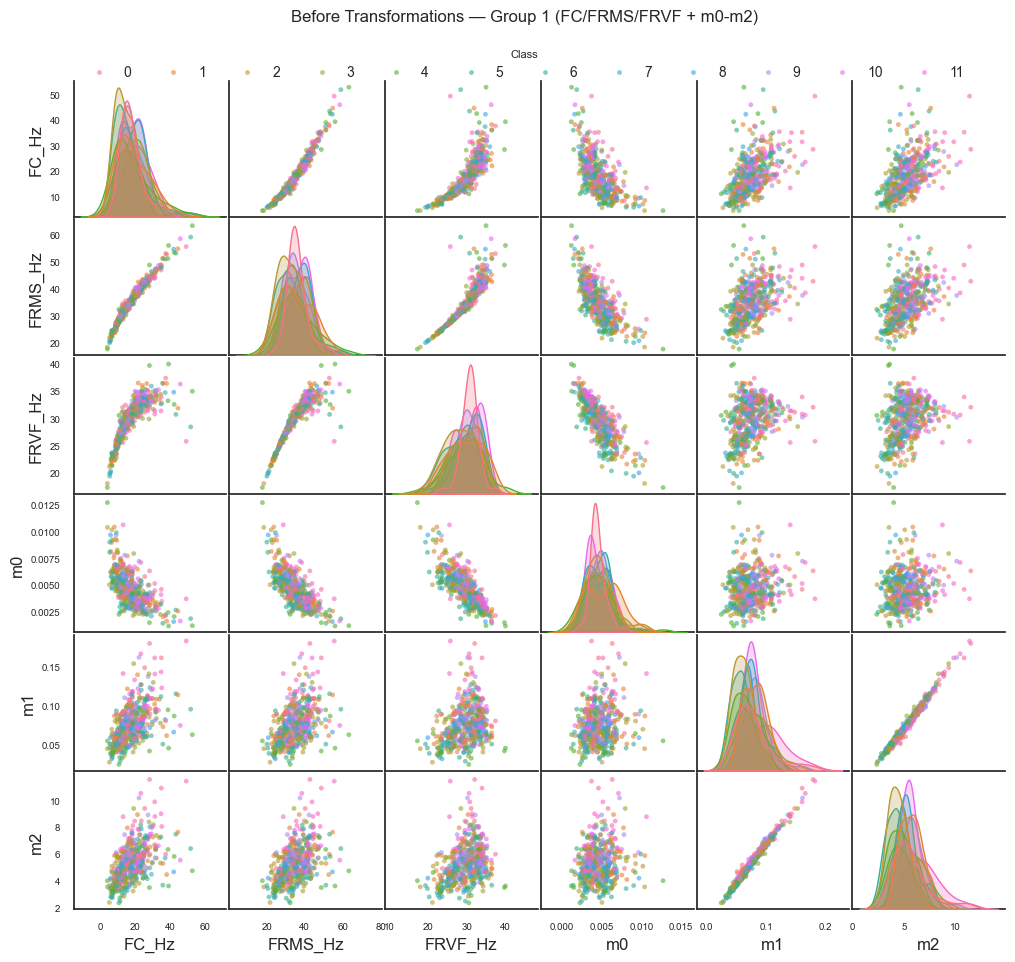

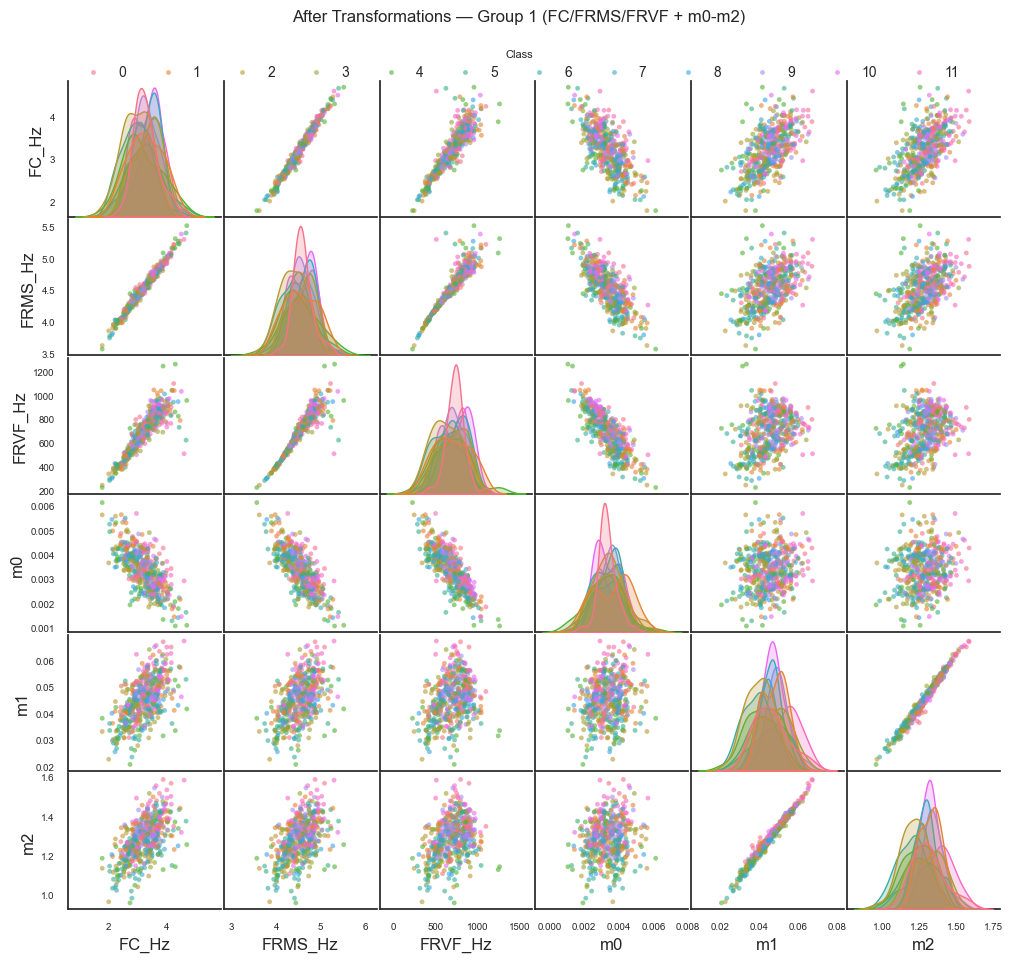

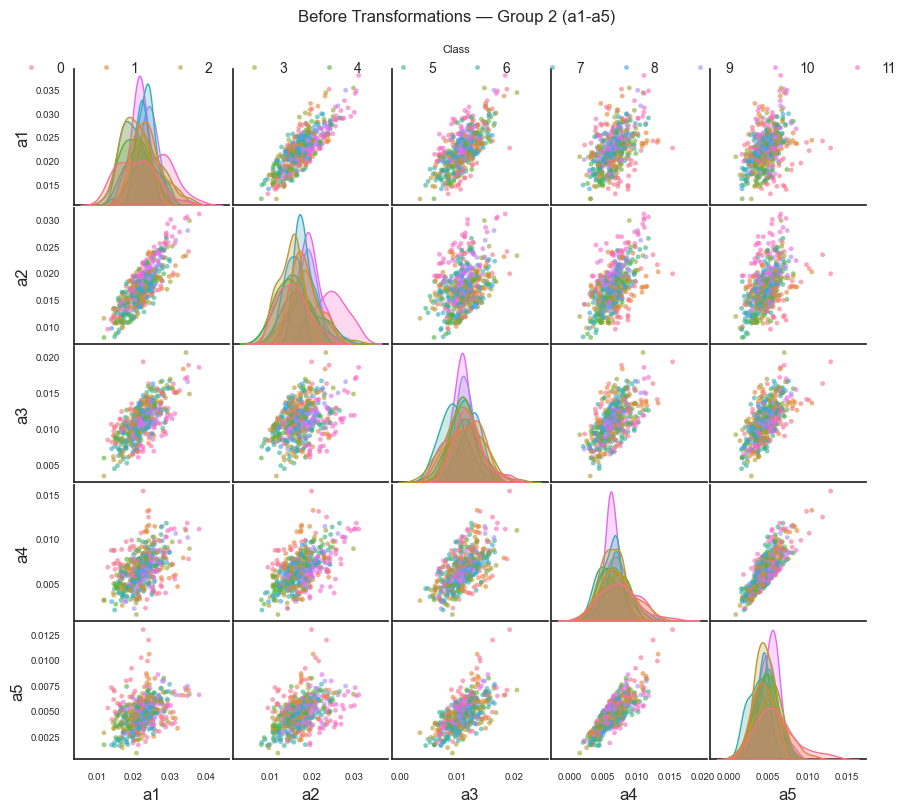

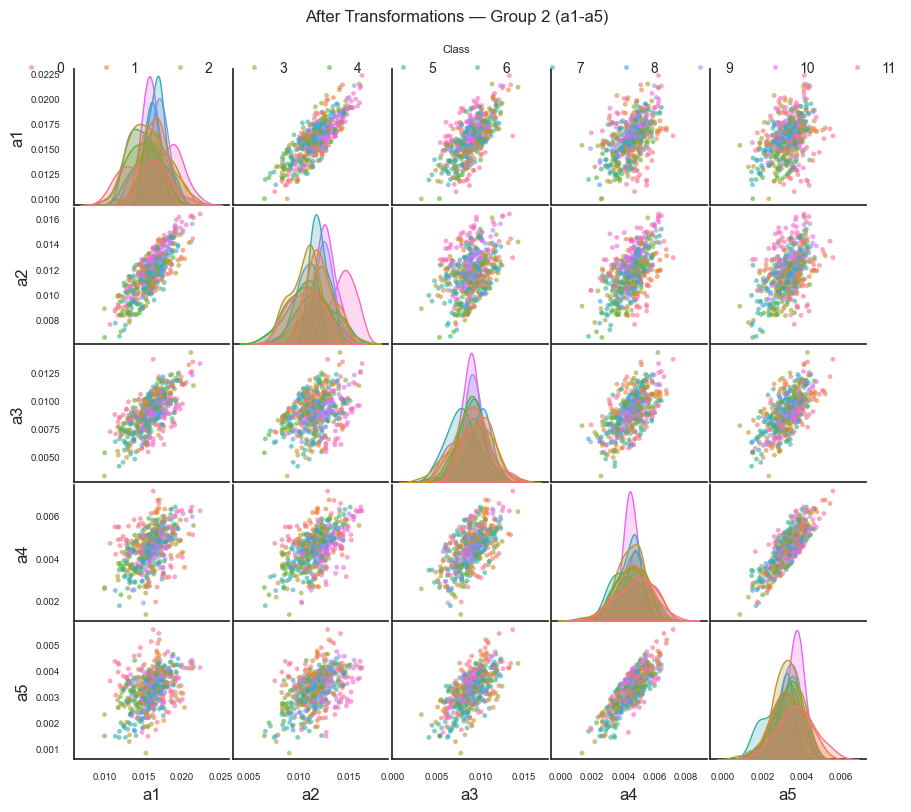

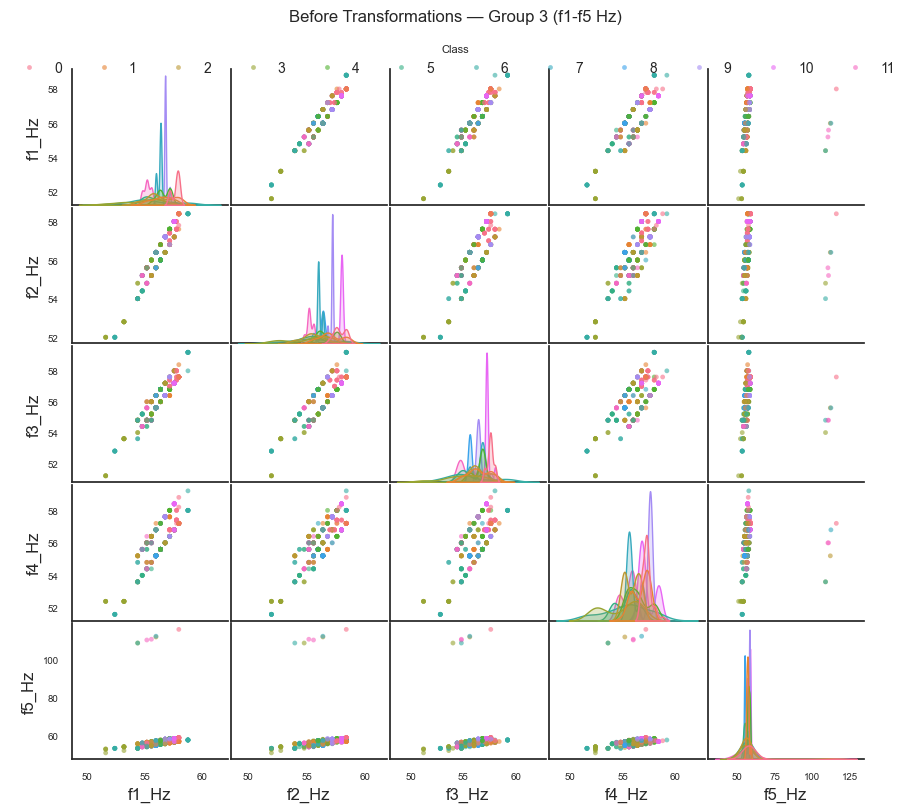

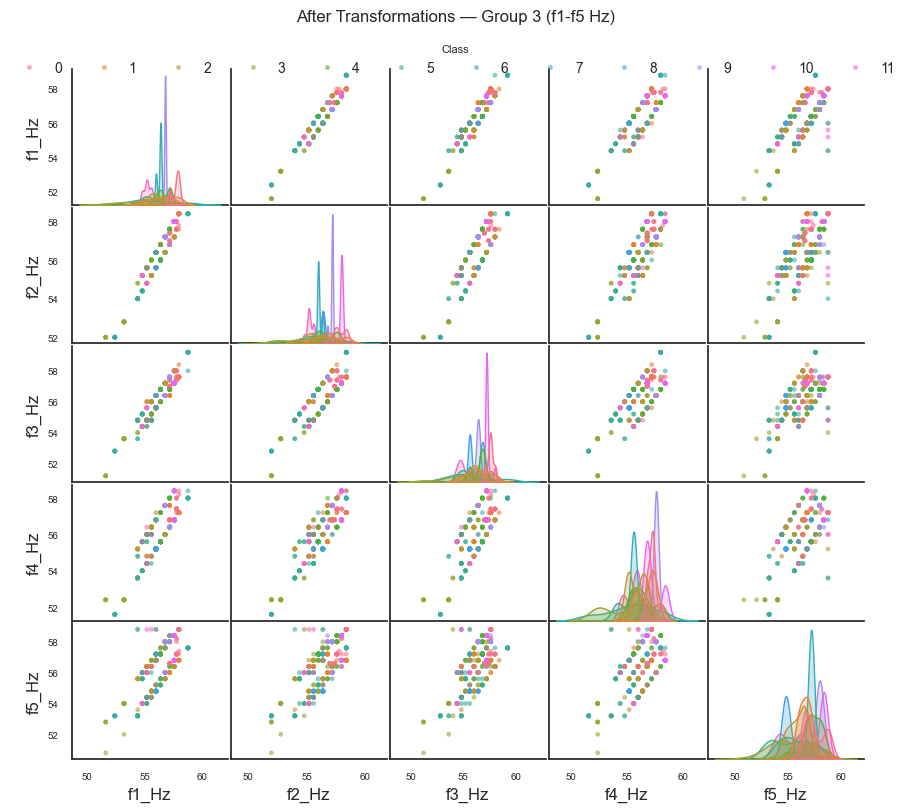

In [13]:
features  = ["FC_Hz","FRMS_Hz","FRVF_Hz","m0","m1","m2"]
features2 = ["a1","a2","a3","a4","a5"]
features3 = ["f1_Hz","f2_Hz","f3_Hz","f4_Hz","f5_Hz"]

groups = {
    "Group 1 (FC/FRMS/FRVF + m0-m2)": features,
    "Group 2 (a1-a5)": features2,
    "Group 3 (f1-f5 Hz)": features3,
}

for name, cols in groups.items():
    make_pairplot_inline(df_before, cols, HUE_COL, f"Before Transformations — {name}", sample=500)
    make_pairplot_inline(df_after,  cols, HUE_COL, f"After Transformations — {name}",  sample=500)

----------------------------------------------
Selection of the Most Relevant Attributes
----------------------------------------------
----------------------------------------------

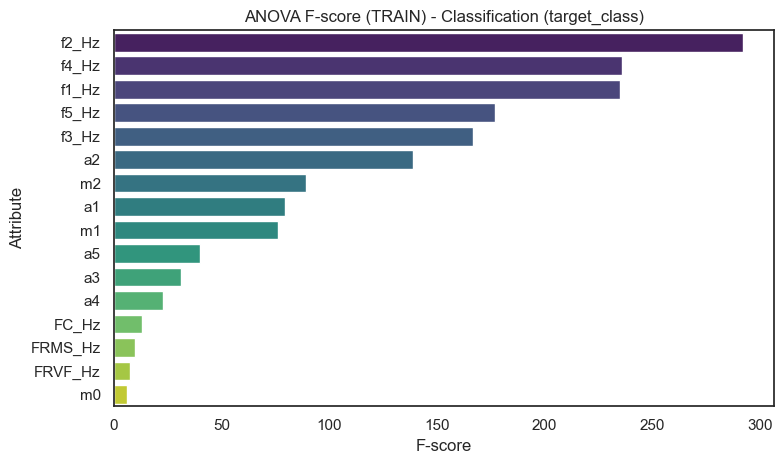

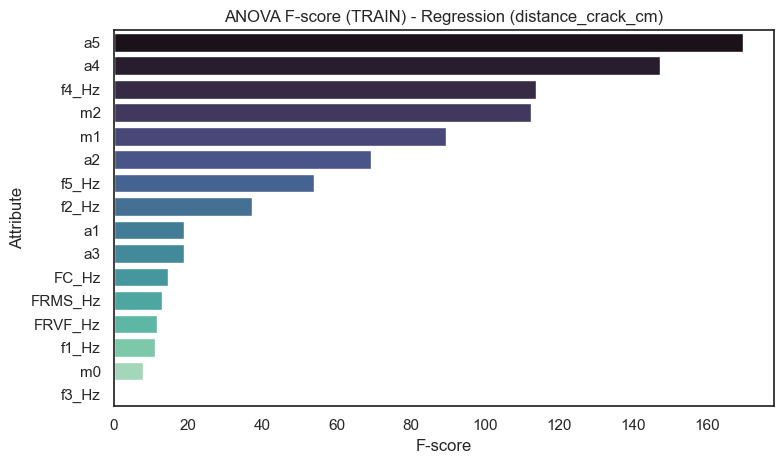

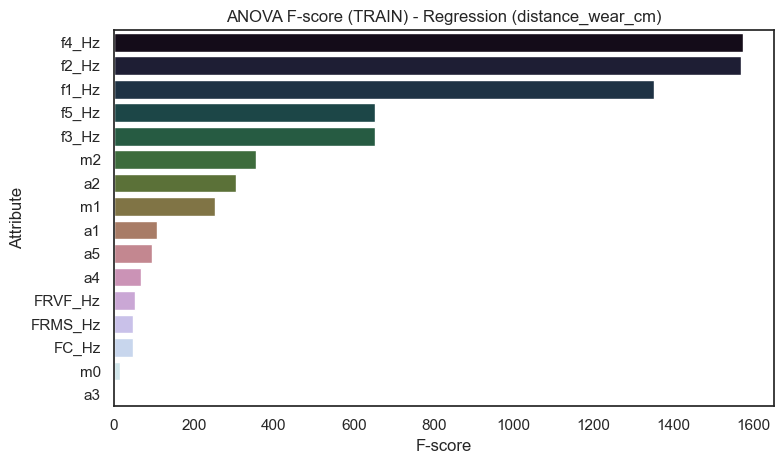

In [14]:
import os, random, numpy as np, pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import f_classif, f_regression

# -------- 1) Selection parameters --------
TOP_K_CLS  = 9
TOP_K_CRACK  = 9
TOP_K_WEAR = 8
USE_P_THRESHOLD = False
P_THRESHOLD = 0.05

PLOT = True

# -------- 2) Utilities --------
def anova_table(X, y, cols, mode="cls"):
    """DataFrame: Attribute, F, p; ordenado por F desc."""
    if mode == "cls":
        F, p = f_classif(X, y)
    else:
        F, p = f_regression(X, y)
    out = pd.DataFrame({"Attribute": cols, "F": F, "p": p})
    return out.sort_values("F", ascending=False).reset_index(drop=True)

def pick_features(df_scores, top_k, use_p=False, p_thr=0.05):
    if use_p:
        sel = df_scores[df_scores["p"] <= p_thr]["Attribute"].tolist()
        if len(sel) == 0:
            sel = df_scores.head(min(top_k, len(df_scores)))["Attribute"].tolist()
    else:
        sel = df_scores.head(min(top_k, len(df_scores)))["Attribute"].tolist()
    return sel

if PLOT:
    import matplotlib.pyplot as plt, seaborn as sns
    def plot_bars(df_scores, title, top_n=25, palette="viridis"):
        dfp = df_scores.head(min(top_n, len(df_scores)))
        plt.figure(figsize=(8, 4.8))
        sns.barplot(data=dfp, x="F", y="Attribute", hue="Attribute", palette=palette, legend=False)
        plt.title(title); plt.xlabel("F-score"); plt.ylabel("Attribute")
        plt.tight_layout(); plt.show()
else:
    def plot_bars(*args, **kwargs):
        pass

# -------- 3) Task-based ANOVA (FIT SOLO TRAIN) --------

# Classification (all train rows)
scores_cls_df = anova_table(X_tr, y_cls_tr, feature_names, mode="cls")
plot_bars(scores_cls_df, "ANOVA F-score (TRAIN) - Classification (target_class)", top_n=25, palette="viridis")

# CRACK Regression (only where there is a valid tag in TRAIN)
mask_crack_tr = sw_crack_tr.astype(bool)
if mask_crack_tr.sum() >= 3:
    scores_crack_df = anova_table(X_tr[mask_crack_tr], y_crack_tr[mask_crack_tr], feature_names, mode="reg")
    plot_bars(scores_crack_df, "ANOVA F-score (TRAIN) - Regression (distance_crack_cm)", top_n=25, palette="mako")
else:
    scores_crack_df = pd.DataFrame({"Attribute": feature_names, "F": np.zeros(len(feature_names)), "p": np.ones(len(feature_names))})

# WEAR Regression (only where there is a valid tag in TRAIN)
mask_wear_tr = sw_wear_tr.astype(bool)
if mask_wear_tr.sum() >= 3:
    scores_wear_df = anova_table(X_tr[mask_wear_tr], y_wear_tr[mask_wear_tr], feature_names, mode="reg")
    plot_bars(scores_wear_df, "ANOVA F-score (TRAIN) - Regression (distance_wear_cm)", top_n=25, palette="cubehelix")
else:
    scores_wear_df = pd.DataFrame({"Attribute": feature_names, "F": np.zeros(len(feature_names)), "p": np.ones(len(feature_names))})

In [15]:
# -------- 4) Selection by task --------
features_cls  = pick_features(scores_cls_df,  TOP_K_CLS,  USE_P_THRESHOLD, P_THRESHOLD)
features_crack  = pick_features(scores_crack_df,  TOP_K_CRACK,  USE_P_THRESHOLD, P_THRESHOLD)
features_wear = pick_features(scores_wear_df, TOP_K_WEAR, USE_P_THRESHOLD, P_THRESHOLD)

print(f"[Selection] Classification ({len(features_cls)}): {features_cls}")
print(f"[Selection] Regression Crack ({len(features_crack)}): {features_crack}")
print(f"[Selection] Regression Wear ({len(features_wear)}): {features_wear}")

# Orderly union without duplicates
union_features = list(dict.fromkeys(features_cls + features_crack + features_wear))
print(f"[UNION] Total number of selected features: {len(union_features)}")
print("[UNION] Features:", union_features)

#--------------------------------------------------------------------------------
# features to remove
MANUAL_DROP = [
    "FRMS_Hz",
    "FRVF_Hz",
    "m0","m1",
]

# Filter only those that actually exist 
drop_present = [f for f in MANUAL_DROP if f in union_features]
drop_missing = [f for f in MANUAL_DROP if f not in union_features]

if len(drop_missing) > 0:
    print("[ManualDrop] Not in union_features (ignored):", drop_missing)

if len(drop_present) > 0:
    print("[ManualDrop] Dropping:", drop_present)

union_features = [f for f in union_features if f not in set(drop_present)]

print(f"[UNION after manual drop] Total selected features: {len(union_features)}")
print("[UNION after manual drop] Features:", union_features)
#--------------------------------------------------------------------------------

idx_union = [feature_names.index(c) for c in union_features]

# Apply selection to train and test (without recalculating anything with test)
X_tr = X_tr[:, idx_union].copy()
X_te = X_te[:, idx_union].copy()

feature_names = union_features

print(f"[X Selected] train={X_tr.shape}  test={X_te.shape}")

[Selection] Classification (9): ['f2_Hz', 'f4_Hz', 'f1_Hz', 'f5_Hz', 'f3_Hz', 'a2', 'm2', 'a1', 'm1']
[Selection] Regression Crack (9): ['a5', 'a4', 'f4_Hz', 'm2', 'm1', 'a2', 'f5_Hz', 'f2_Hz', 'a1']
[Selection] Regression Wear (8): ['f4_Hz', 'f2_Hz', 'f1_Hz', 'f5_Hz', 'f3_Hz', 'm2', 'a2', 'm1']
[UNION] Total number of selected features: 11
[UNION] Features: ['f2_Hz', 'f4_Hz', 'f1_Hz', 'f5_Hz', 'f3_Hz', 'a2', 'm2', 'a1', 'm1', 'a5', 'a4']
[ManualDrop] Not in union_features (ignored): ['FRMS_Hz', 'FRVF_Hz', 'm0']
[ManualDrop] Dropping: ['m1']
[UNION after manual drop] Total selected features: 10
[UNION after manual drop] Features: ['f2_Hz', 'f4_Hz', 'f1_Hz', 'f5_Hz', 'f3_Hz', 'a2', 'm2', 'a1', 'a5', 'a4']
[X Selected] train=(2880, 10)  test=(720, 10)


----------------------------------------------
Data Normalization
----------------------------------------------
----------------------------------------------

In [16]:
from sklearn.preprocessing import RobustScaler

X_tr = X_tr.copy()
X_te = X_te.copy()

scaler = RobustScaler(
    with_centering=True,
    with_scaling=True,
    quantile_range=(25.0, 75.0) 
)

# Fit ONLY in training
X_tr = scaler.fit_transform(X_tr)

# Transform in test using parameters from train
X_te = scaler.transform(X_te)

print("[Scaler] RobustScaler fitted on TRAIN and applied to TRAIN/TEST")
print(f"[Scaler] Shapes -> train={X_tr.shape}  test={X_te.shape}")

[Scaler] RobustScaler fitted on TRAIN and applied to TRAIN/TEST
[Scaler] Shapes -> train=(2880, 10)  test=(720, 10)


In [ ]:
# ============================================================
# Single-task models (regressión crack)
# ============================================================

import numpy as np

_needed = ["X_tr","X_te","y_crack_tr","y_crack_te","sw_crack_tr","sw_crack_te"]
assert all(v in globals() for v in _needed), "Missing variables for CRACK regression."

mask_crack_tr = sw_crack_tr.astype(bool)
mask_crack_te = sw_crack_te.astype(bool)

X_tr_crack = X_tr[mask_crack_tr].copy()
y_tr_crack = y_crack_tr[mask_crack_tr].astype(np.float64).copy()

X_te_crack = X_te[mask_crack_te].copy()
y_te_crack = y_crack_te[mask_crack_te].astype(np.float64).copy()

print(f"[CRACK] mask_crack_tr positives: {mask_crack_tr.sum()} / {len(mask_crack_tr)}")
print(f"[CRACK] mask_crack_te positives: {mask_crack_te.sum()} / {len(mask_crack_te)}")
print(f"[CRACK] Shapes -> train={X_tr_crack.shape}  test={X_te_crack.shape}")


[CRACK] mask_crack_tr positives: 1920 / 2880
[CRACK] mask_crack_te positives: 480 / 720
[CRACK] Shapes -> train=(1920, 10)  test=(480, 10)


----------------------------------------------
Hyperparameter Tuning
----------------------------------------------
----------------------------------------------

In [18]:
# ============================================================
# Single-task models (regression) + GRIDSEARCHCV
# Train only where crack_mask==1
# Export: best models (.pkl) + summary table (CSV)
# ============================================================

import os, numpy as np, pandas as pd, joblib
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -----------------------------
# 0) Variable verification
# -----------------------------
_req = ["X_tr_crack","y_tr_crack","X_te_crack","y_te_crack","SEED"]
assert all(v in globals() for v in _req), \
    "Missing variables. Run preprocessing + CRACK dataset cell first."

X_train = np.asarray(X_tr_crack)
y_train = np.asarray(y_tr_crack).astype(float)
X_test  = np.asarray(X_te_crack)
y_test  = np.asarray(y_te_crack).astype(float)

print(f"[CRACK-REG] X_train={X_train.shape} X_test={X_test.shape}")

# ---------------------------------------------------------
# 1) Cross-validation - 10 folds
# ---------------------------------------------------------
cv10 = KFold(n_splits=10, shuffle=True, random_state=SEED)

# ---------------------------------------------------------
# 2) Define models and grids
# ---------------------------------------------------------
models_and_grids = {
    "Ridge": (
        Pipeline([("reg", Ridge())]),
        {"reg__alpha": [0.01, 0.1, 1, 10, 100]}
    ),
    "Lasso": (
        Pipeline([("reg", Lasso(max_iter=20000))]),
        {"reg__alpha": [0.0001, 0.001, 0.01, 0.1, 1]}
    ),
    "ElasticNet": (
        Pipeline([("reg", ElasticNet(max_iter=20000))]),
        {
            "reg__alpha": [0.001, 0.01, 0.1, 1, 10],
            "reg__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
        }
    ),
    "KNN": (
        Pipeline([("reg", KNeighborsRegressor())]),
        {
            "reg__n_neighbors": [11, 13, 15, 21, 29, 41, 61],
            "reg__weights": ["uniform"],     # evita memorizar
            "reg__metric": ["euclidean", "manhattan", "minkowski", "chebyshev"],
            "reg__p": [1, 2], 
        }
    ),
    "SVR": (
    Pipeline([("reg", SVR())]),
    {
        "reg__kernel": ["rbf", "linear"],
        "reg__C": [0.1, 1, 10, 100],
        "reg__gamma": ["scale", 0.01, 0.1],  
        "reg__epsilon": [0.01, 0.1, 0.25],  
    }
),
    "DecisionTree": (
        Pipeline([("reg", DecisionTreeRegressor(random_state=SEED))]),
        {
            "reg__max_depth": [2, 3, 4, 5, 6],
            "reg__min_samples_split": [5, 10, 20],
            "reg__min_samples_leaf": [5, 10, 20],
            "reg__max_features": ["sqrt", "log2"],  
            "reg__ccp_alpha": [0.0, 1e-4, 1e-3, 1e-2],

            "reg__criterion": ["squared_error", "absolute_error"],
            "reg__splitter": ["best", "random"],
        }
    ),
    "MLP": (
        Pipeline([("reg", MLPRegressor(max_iter=300, random_state=SEED))]),
        {
            "reg__hidden_layer_sizes": [(10,), (50,), (100,), (10, 50), (50, 100), (50, 50), (10, 10, 10)],
            "reg__activation": ["relu", "tanh", "logistic"],
            "reg__solver": ["adam", "sgd"],
            "reg__alpha": [0.0001, 0.001, 0.01],
            "reg__learning_rate": ["constant"],
        }
    ),
}

# ---------------------------------------------------------
# 3) Train GridSearch for each model
# scoring: MAE
# ---------------------------------------------------------
RESULTS_DIR = "crack_reg_grid_models"
os.makedirs(RESULTS_DIR, exist_ok=True)

rows = []
best_models = {}

for name, (pipe, grid) in models_and_grids.items():
    print("\n" + "="*70)
    print(f"[GridSearch - CRACK REG] {name}")
    print("="*70)

    gs = GridSearchCV(
        estimator=pipe,
        param_grid=grid,
        scoring="neg_mean_absolute_error",
        cv=cv10,
        n_jobs=-1,
        verbose=1,
        refit=True,
        return_train_score=True
    )

    gs.fit(X_train, y_train)

    print(f"[{name}] Best CV MAE: {-gs.best_score_:.4f} cm")
    print(f"[{name}] Best params: {gs.best_params_}")

    best_est = gs.best_estimator_
    best_models[name] = best_est

    y_pred = best_est.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    r2   = float(r2_score(y_test, y_pred))

    print(f"[{name}] TEST -> MAE={mae:.4f} | RMSE={rmse:.4f} | R2={r2:.4f}")

    out_pkl = os.path.join(RESULTS_DIR, f"best_{name}_crack_reg.pkl")
    joblib.dump(best_est, out_pkl)
    print(f"[{name}] Model exported -> {out_pkl}")

    rows.append({
        "model": name,
        "best_cv_mae": float(-gs.best_score_),
        "test_mae": float(mae),
        "test_rmse": float(rmse),
        "test_r2": float(r2),
        "best_params": str(gs.best_params_),
        "model_path": out_pkl
    })

# ---------------------------------------------------------
# 4) Summary table sorted by test_mae
# ---------------------------------------------------------
df_results = pd.DataFrame(rows).sort_values("test_mae", ascending=True).reset_index(drop=True)

print("\n" + "="*70)
print("[SUMMARY] CRACK regression models ranked by TEST MAE (lower is better)")
print("="*70)
with pd.option_context("display.max_colwidth", 200, "display.width", 200):
    print(df_results[["model","best_cv_mae","test_mae","test_rmse","test_r2","model_path","best_params"]])

out_csv = os.path.join(RESULTS_DIR, "crack_regression_grid_results.csv")
df_results.to_csv(out_csv, index=False)
print(f"\n[SUMMARY] Results exported -> {out_csv}")

best_name = df_results.loc[0, "model"]
print("\n" + "="*70)
print(f"[BEST] Best CRACK regressor by TEST MAE: {best_name}")
print("="*70)
print(best_models[best_name])

[CRACK-REG] X_train=(1920, 10) X_test=(480, 10)

[GridSearch - CRACK REG] Ridge
Fitting 10 folds for each of 5 candidates, totalling 50 fits
[Ridge] Best CV MAE: 1.5545 cm
[Ridge] Best params: {'reg__alpha': 0.01}
[Ridge] TEST -> MAE=1.5349 | RMSE=1.7761 | R2=0.2189
[Ridge] Model exported -> crack_reg_grid_models\best_Ridge_crack_reg.pkl

[GridSearch - CRACK REG] Lasso
Fitting 10 folds for each of 5 candidates, totalling 50 fits
[Lasso] Best CV MAE: 1.5546 cm
[Lasso] Best params: {'reg__alpha': 0.0001}
[Lasso] TEST -> MAE=1.5351 | RMSE=1.7760 | R2=0.2189
[Lasso] Model exported -> crack_reg_grid_models\best_Lasso_crack_reg.pkl

[GridSearch - CRACK REG] ElasticNet
Fitting 10 folds for each of 25 candidates, totalling 250 fits
[ElasticNet] Best CV MAE: 1.5560 cm
[ElasticNet] Best params: {'reg__alpha': 0.001, 'reg__l1_ratio': 0.9}
[ElasticNet] TEST -> MAE=1.5370 | RMSE=1.7753 | R2=0.2196
[ElasticNet] Model exported -> crack_reg_grid_models\best_ElasticNet_crack_reg.pkl

[GridSearch - CRAC

c:\Users\axelr\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


In [19]:
# ============================================================
# EVALUATION OF REGRESSION MODELS (TEST SET)
# ============================================================

import os, joblib, numpy as np, pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def safe_mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps))) * 100.0

_req = ["X_te_crack","y_te_crack"]
assert all(v in globals() for v in _req), "Missing X_te_crack / y_te_crack."

X_test = np.asarray(X_te_crack)
y_test = np.asarray(y_te_crack).astype(float)

MODELS_DIR = "crack_reg_grid_models"

models = {
    "Ridge": joblib.load(os.path.join(MODELS_DIR, "best_Ridge_crack_reg.pkl")),
    "Lasso": joblib.load(os.path.join(MODELS_DIR, "best_Lasso_crack_reg.pkl")),
    "ElasticNet": joblib.load(os.path.join(MODELS_DIR, "best_ElasticNet_crack_reg.pkl")),
    "KNN": joblib.load(os.path.join(MODELS_DIR, "best_KNN_crack_reg.pkl")),
    "SVR": joblib.load(os.path.join(MODELS_DIR, "best_SVR_crack_reg.pkl")),
    "DecisionTree": joblib.load(os.path.join(MODELS_DIR, "best_DecisionTree_crack_reg.pkl")),
    "MLP": joblib.load(os.path.join(MODELS_DIR, "best_MLP_crack_reg.pkl")),
}

metrics = {}

for name, model in models.items():
    y_pred = model.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    r2   = float(r2_score(y_test, y_pred))
    mape = float(safe_mape(y_test, y_pred))

    metrics[name] = {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE (%)": mape
    }

df_metrics_test = pd.DataFrame(metrics).T.sort_values("MAE", ascending=True)

print("\n" + "="*70)
print("[SUMMARY] CRACK regression TEST metrics (sorted by MAE)")
print("="*70)
with pd.option_context("display.width", 160):
    print(df_metrics_test)

df_metrics_test.to_csv(os.path.join(MODELS_DIR, "crack_regression_test_metrics.csv"))
print("\n[Export] crack_regression_test_metrics.csv saved")


[SUMMARY] CRACK regression TEST metrics (sorted by MAE)
                   MAE      RMSE        R2   MAPE (%)
KNN           0.144318  0.458299  0.947991   3.782160
SVR           0.242897  0.516874  0.933848   7.263499
MLP           0.247961  0.382278  0.963814   7.429460
DecisionTree  0.375550  0.697806  0.879428  10.094714
Ridge         1.534889  1.776115  0.218877  48.533309
Lasso         1.535112  1.776045  0.218938  48.543668
ElasticNet    1.537025  1.775329  0.219568  48.626593

[Export] crack_regression_test_metrics.csv saved


In [20]:
# ============================================================
# EVALUATION OF REGRESSION MODELS (TRAIN SET)
# (to compare vs TEST and detect overfitting)
# ============================================================

import os, joblib, numpy as np, pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def safe_mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps))) * 100.0

_req = ["X_tr_crack","y_tr_crack"]
assert all(v in globals() for v in _req), "Missing X_tr_crack / y_tr_crack."

X_train = np.asarray(X_tr_crack)
y_train = np.asarray(y_tr_crack).astype(float)

MODELS_DIR = "crack_reg_grid_models"

models = {
    "Ridge": joblib.load(os.path.join(MODELS_DIR, "best_Ridge_crack_reg.pkl")),
    "Lasso": joblib.load(os.path.join(MODELS_DIR, "best_Lasso_crack_reg.pkl")),
    "ElasticNet": joblib.load(os.path.join(MODELS_DIR, "best_ElasticNet_crack_reg.pkl")),
    "KNN": joblib.load(os.path.join(MODELS_DIR, "best_KNN_crack_reg.pkl")),
    "SVR": joblib.load(os.path.join(MODELS_DIR, "best_SVR_crack_reg.pkl")),
    "DecisionTree": joblib.load(os.path.join(MODELS_DIR, "best_DecisionTree_crack_reg.pkl")),
    "MLP": joblib.load(os.path.join(MODELS_DIR, "best_MLP_crack_reg.pkl")),
}

metrics = {}

for name, model in models.items():
    y_pred = model.predict(X_train)

    mae  = mean_absolute_error(y_train, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_train, y_pred)))
    r2   = float(r2_score(y_train, y_pred))
    mape = float(safe_mape(y_train, y_pred))

    metrics[name] = {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE (%)": mape
    }

df_metrics_train = pd.DataFrame(metrics).T.sort_values("MAE", ascending=True)
print("\n" + "="*70)
print("[SUMMARY] CRACK regression TRAIN metrics (sorted by MAE)")
print("="*70)
with pd.option_context("display.width", 160):
    print(df_metrics_train)

df_metrics_train.to_csv(os.path.join(MODELS_DIR, "crack_regression_train_metrics.csv"))
print("\n[Export] crack_regression_train_metrics.csv saved")



[SUMMARY] CRACK regression TRAIN metrics (sorted by MAE)
                   MAE      RMSE        R2   MAPE (%)
SVR           0.112363  0.294305  0.978368   3.125113
KNN           0.135511  0.413080  0.957385   3.756626
MLP           0.168837  0.261288  0.982949   4.918133
DecisionTree  0.330082  0.660817  0.890941   8.922779
Ridge         1.544181  1.742865  0.241375  47.150903
Lasso         1.544359  1.742866  0.241374  47.157564
ElasticNet    1.546167  1.742968  0.241285  47.221497

[Export] crack_regression_train_metrics.csv saved
